In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [2]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
stocks = ['AAPL','MSFT','GOOGL','AMZN','TSLA',
          'NVDA','META','NFLX','INTC','IBM']


In [24]:
import yfinance as yf
import pandas as pd
import os

# List of stocks
stocks = ['AAPL','MSFT','GOOGL','AMZN','TSLA','NVDA','META','NFLX','INTC','IBM']

# Date range
start_date = "2015-01-01"
end_date = "2025-01-01"

# Create folder (optional)
os.makedirs("stock_data", exist_ok=True)

for stock in stocks:
    print(f"📥 Downloading {stock}...")

    df = yf.download(stock, start=start_date, end=end_date)

    if df.empty:
        print(f"❌ No data for {stock}")
        continue

    # Save CSV
    file_path = f"stock_data/{stock}.csv"
    df.to_csv(file_path)

    print(f"✅ Saved {stock} to {file_path}")

print("\n🎉 All downloads complete!")


[*********************100%***********************]  1 of 1 completed

📥 Downloading AAPL...
✅ Saved AAPL to stock_data/AAPL.csv
📥 Downloading MSFT...



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


✅ Saved MSFT to stock_data/MSFT.csv
📥 Downloading GOOGL...
✅ Saved GOOGL to stock_data/GOOGL.csv
📥 Downloading AMZN...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


...

✅ Saved NVDA to stock_data/NVDA.csv
📥 Downloading META...
✅ Saved META to stock_data/META.csv
📥 Downloading NFLX...



[*********************100%***********************]  1 of 1 completed


✅ Saved NFLX to stock_data/NFLX.csv
📥 Downloading INTC...
✅ Saved INTC to stock_data/INTC.csv
📥 Downloading IBM...


[*********************100%***********************]  1 of 1 completed

✅ Saved IBM to stock_data/IBM.csv

🎉 All downloads complete!


In [5]:
data = {}

for stock in stocks:
    print(f"Downloading {stock}...")
    df = yf.download(stock, start="2015-01-01", end="2025-01-01")
    data[stock] = df


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


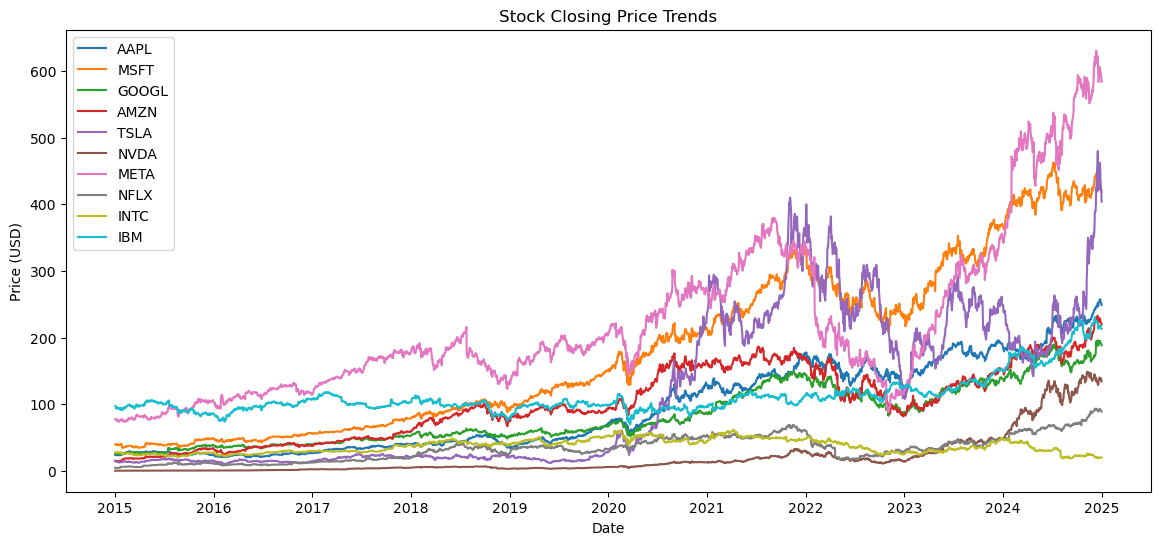

In [6]:
plt.figure(figsize=(14,6))

for stock in stocks:
    plt.plot(data[stock]['Close'], label=stock)

plt.title("Stock Closing Price Trends")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


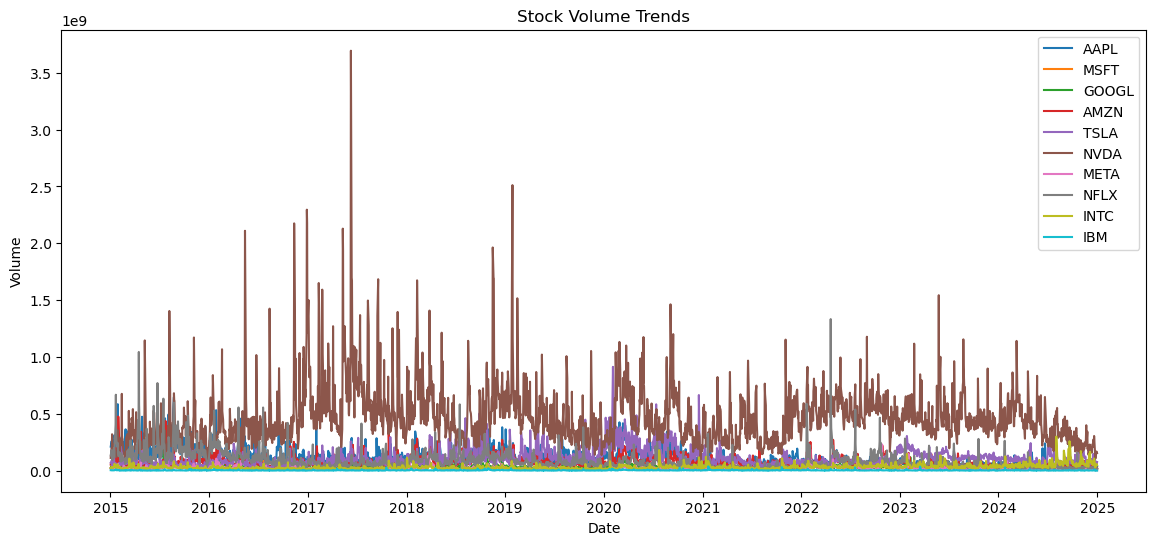

In [7]:
plt.figure(figsize=(14,6))

for stock in stocks:
    plt.plot(data[stock]['Volume'], label=stock)

plt.title("Stock Volume Trends")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.show()


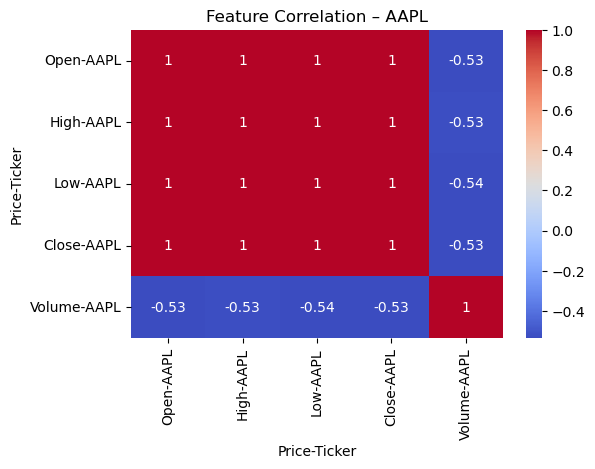

In [8]:
plt.figure(figsize=(6,4))

sns.heatmap(data['AAPL'][['Open','High','Low','Close','Volume']].corr(),
            annot=True, cmap='coolwarm')

plt.title("Feature Correlation – AAPL")
plt.show()


In [9]:
sequence_length = 60
models_performance = {}

early_stop = EarlyStopping(monitor='val_loss',
                           patience=5,
                           restore_best_weights=True)


In [10]:
for stock in stocks:

    print(f"\n📈 Training model for {stock}")

    df = data[stock].dropna()

    # MULTIPLE FEATURES
    dataset = df[['Open','High','Low','Close','Volume']]

    scaler = MinMaxScaler(feature_range=(0,1))
    scaled_data = scaler.fit_transform(dataset)

    X, y = [], []

    for i in range(sequence_length, len(scaled_data)):
        X.append(scaled_data[i-sequence_length:i])
        y.append(scaled_data[i, 3])  # Close price index = 3

    X, y = np.array(X), np.array(y)

    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = Sequential()
    model.add(Input(shape=(60, 5)))  # 5 features

    model.add(LSTM(100, return_sequences=True))
    model.add(Dropout(0.2))

    model.add(LSTM(100, return_sequences=True))
    model.add(Dropout(0.2))

    model.add(LSTM(100))
    model.add(Dropout(0.2))

    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mean_squared_error')

    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        verbose=0
    )

    # Predictions
    predictions = model.predict(X_test)

    # Inverse transform (only Close)
    dummy = np.zeros((len(predictions), 5))
    dummy[:, 3] = predictions[:, 0]
    predictions = scaler.inverse_transform(dummy)[:, 3]

    actual_dummy = np.zeros((len(y_test), 5))
    actual_dummy[:, 3] = y_test
    actual = scaler.inverse_transform(actual_dummy)[:, 3]

    rmse = np.sqrt(mean_squared_error(actual, predictions))
    models_performance[stock] = rmse

    print(f"✅ RMSE: {rmse:.2f}")

    model.save(f"models/{stock}_model.keras")



📈 Training model for AAPL
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step
✅ RMSE: 7.27

📈 Training model for MSFT
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step
✅ RMSE: 12.61

📈 Training model for GOOGL
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
✅ RMSE: 14.74

📈 Training model for AMZN
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
✅ RMSE: 11.07

📈 Training model for TSLA
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step
✅ RMSE: 26.98

📈 Training model for NVDA
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step
✅ RMSE: 20.98

📈 Training model for META
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step
✅ RMSE: 43.52

📈 Training model for NFLX
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step
✅ RMSE: 3.86

📈 Training model for INTC
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step
✅ RMSE: 2.59

📈 Training model for IBM
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step
✅ RMSE: 9.01


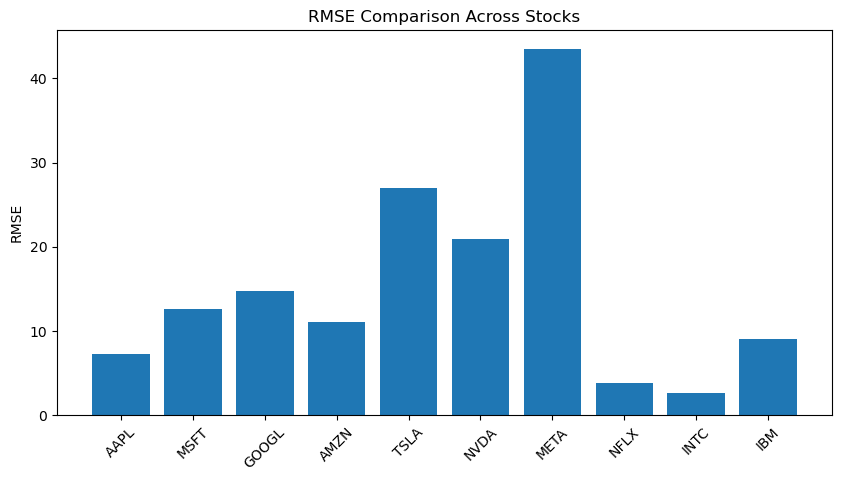

In [11]:
plt.figure(figsize=(10,5))
plt.bar(models_performance.keys(), models_performance.values())

plt.title("RMSE Comparison Across Stocks")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()


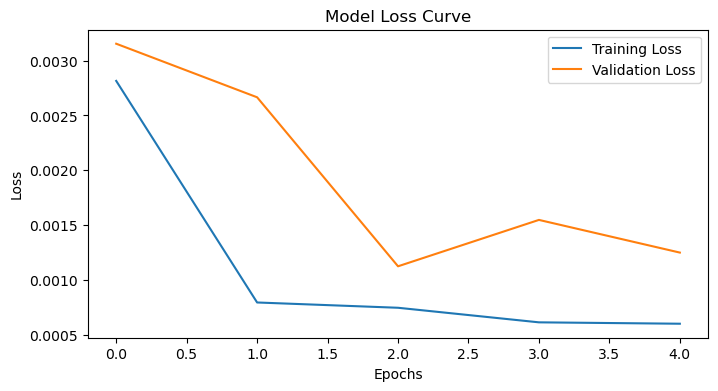

In [12]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


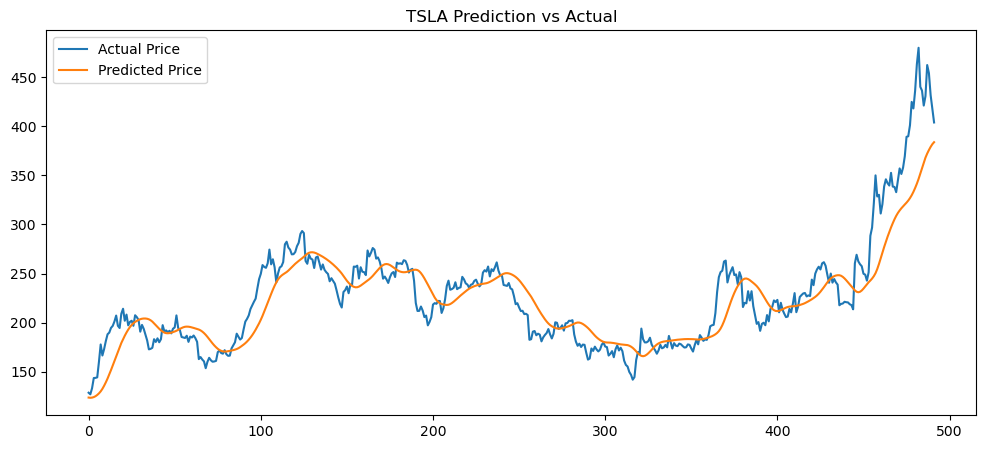

In [13]:
stock = 'TSLA'
df = data[stock].dropna()
dataset = df[['Open','High','Low','Close','Volume']]
dummy = np.zeros((len(predictions), 5))
dummy[:, 3] = predictions[:, 0]
predictions = scaler.inverse_transform(dummy)[:, 3]

actual_dummy = np.zeros((len(y_test), 5))
actual_dummy[:, 3] = y_test
actual = scaler.inverse_transform(actual_dummy)[:, 3]




In [16]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

In [17]:
X, y = [], []
for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i, 3])

In [18]:
X, y = np.array(X), np.array(y)

split = int(0.8 * len(X))
X_test = X[split:]
y_test = y[split:]


In [22]:
from tensorflow.keras.models import load_model
model = load_model(f"models/{stock}_model.keras")

predictions = model.predict(X_test)


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step


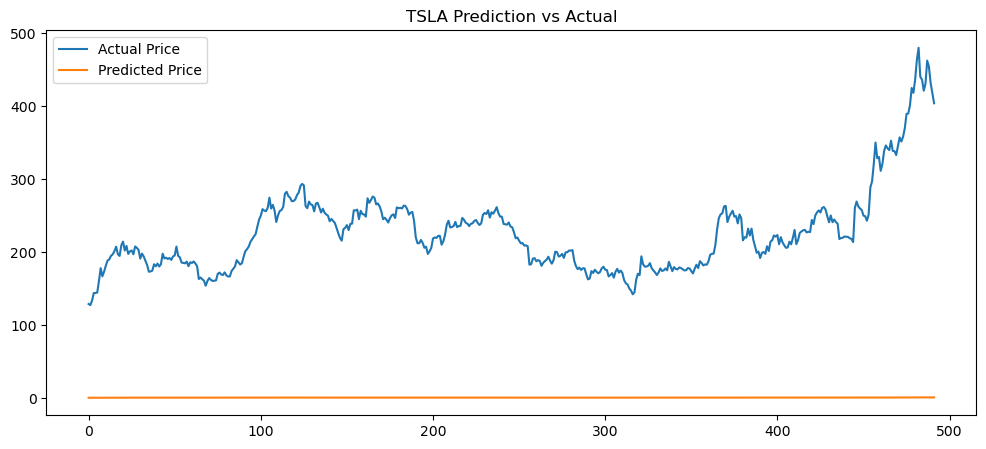

In [23]:
plt.figure(figsize=(12,5))
plt.plot(actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.title(f"{stock} Prediction vs Actual")
plt.legend()
plt.show()